## How to use this notebook

- **Single-run cells**: The initial code cells run one simulation for the default and balanced segment-mix scenarios and are used by the Gantt / single-permit views.
- **Multi-run cells**: The later cells that call `run_multiple_simulations` repeat both scenarios many times and feed the aggregate statistics and box/whisker plots.
- **Workflow**: Run the single-run block first (to keep Gantt charts tied to one run), then run the multi-run block so the segment comparison plots reflect many simulations.

In [1]:
from run_simulation import run_simulation, print_statistics
import simpy

# Run the simulation
num_permits = 6571
print("Running simulation with " + str(num_permits) + " permits...")
# Scenario 1: Default segment allocation (~90% custom, 2% pre-approved, 8% self-cert, 80% like-for-like)
sim_default = run_simulation(
    num_permits=num_permits,
    random_seed=42,
    inter_arrival_time=0,
    sequential = "standard",
)
sim = sim_default  # for backward compatibility with other cells

# Get and display statistics
stats = sim_default.get_statistics()
print_statistics(stats)

Running simulation with 6571 permits...

SIMULATION STATISTICS

Total Completed Permits: 6546
Total In Progress: 25

--------------------------------------------------------------------------------
SEGMENT DISTRIBUTION
--------------------------------------------------------------------------------
  CUSTOM_LIKE                   : 4736 (72.35%)
  CUSTOM_NON_LIKE               : 1167 (17.83%)
  PRE_APPROVED_LIKE             :   95 ( 1.45%)
  PRE_APPROVED_NON_LIKE         :   21 ( 0.32%)
  SELF_CERT_LIKE                :  432 ( 6.60%)
  SELF_CERT_NON_LIKE            :   95 ( 1.45%)

--------------------------------------------------------------------------------
OVERALL PROCESSING TIME STATISTICS
--------------------------------------------------------------------------------
  Mean:     772.24 days
  Median:   574.50 days
  Std Dev:  633.30 days
  Min:       87.36 days
  Max:     4979.33 days

--------------------------------------------------------------------------------
PROCESSING T

In [2]:
from permit_simulation import epa_debris_calendar_metrics, usace_debris_calendar_metrics

# One value per simulation: earliest debris job start and latest job end (across all permits).

epa = epa_debris_calendar_metrics(sim.completed_permits)
usace = usace_debris_calendar_metrics(sim.completed_permits)

print("This simulation — EPA / USACE debris (days from t=0)\n")
print("  First start = earliest service start; last end = latest service end.\n")

if epa["first_service_start"] is not None and epa["last_service_end"] is not None:
    print(
        f"  EPA:   first start = {epa['first_service_start']:.2f}, "
        f"last end = {epa['last_service_end']:.2f}"
    )
else:
    print("  EPA:   (no timestamps)")

if usace["first_service_start"] is not None and usace["last_service_end"] is not None:
    print(
        f"  USACE: first start = {usace['first_service_start']:.2f}, "
        f"last end = {usace['last_service_end']:.2f}"
    )
else:
    print("  USACE: (no timestamps)")


This simulation — EPA / USACE debris (days from t=0)

  First start = earliest service start; last end = latest service end.

  EPA:   first start = 23.00, last end = 65.72
  USACE: first start = 23.00, last end = 166.36


In [3]:
from run_simulation import run_multiple_simulations
import numpy as np

In [4]:
# Optional: Access individual permit data
print(f"\nFirst 5 completed permits:")
for permit in sim.completed_permits[:5]:
    total_time = permit.ready_for_construction - permit.created_at if permit.ready_for_construction else None
    print(f"  Permit {permit.permit_id} ({permit.segment.name}): "
          f"{total_time:.2f} days total, "
          f"{permit.public_works_rechecks} re-checks")



First 5 completed permits:
  Permit 4640 (CUSTOM_LIKE): 87.36 days total, 1 re-checks
  Permit 2745 (CUSTOM_LIKE): 91.43 days total, 0 re-checks
  Permit 1563 (CUSTOM_LIKE): 92.41 days total, 1 re-checks
  Permit 545 (CUSTOM_LIKE): 92.75 days total, 0 re-checks
  Permit 6195 (CUSTOM_LIKE): 96.68 days total, 1 re-checks


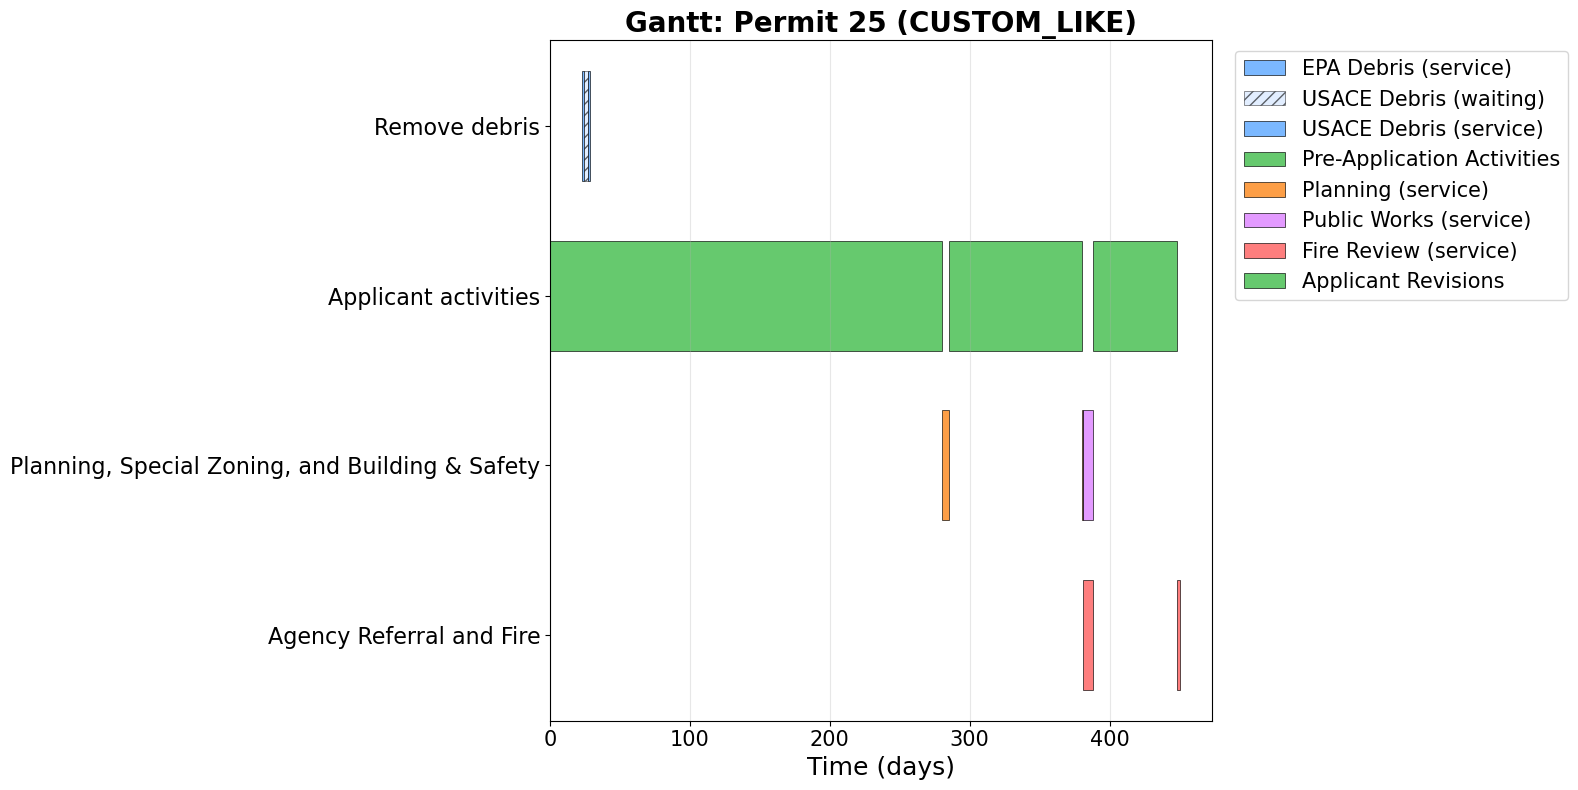

Permit(permit_id=25, segment=<Segment.CUSTOM_LIKE: 3>, created_at=0, debris_removal_request=23, debris_removal_service_start=23, debris_removal_end=28.970172844003905, epa_debris_request=23, epa_debris_service_start=23, epa_debris_end=24.664083026978666, epa_debris_total_waiting=0.0, usace_debris_request=24.664083026978666, usace_debris_service_start=26.970172844003905, usace_debris_end=28.970172844003905, usace_debris_total_waiting=2.3060898170252386, authorization_start=None, authorization_end=None, plan_prep_start=0, plan_prep_end=np.float64(279.98216041608947), planning_request=np.float64(279.98216041608947), planning_service_start=np.float64(279.98216041608947), planning_end=np.float64(381.35879379146263), planning_total_waiting=np.float64(0.0), planning_rechecks=1, planning_initial_waiting=np.float64(0.0), planning_initial_service=np.float64(5.424790933736176), planning_recheck_waiting=np.float64(0.0), planning_recheck_service=np.float64(1.2512029217064082), planning_reviewer_sta

In [5]:
# Gantt chart for one random permit in segment 4 (CUSTOM_NON_LIKE)
# Parallel activities (e.g. Public Works, Fire Review, Public Health) appear on separate rows
from visualize_permits import plot_gantt_single_permit
import matplotlib.pyplot as plt

x = 2345

fig, ax = plot_gantt_single_permit(
    sim.completed_permits[x],
    figsize=(16, 8), 
)
if fig:
    plt.show()

print(sim.completed_permits[x])

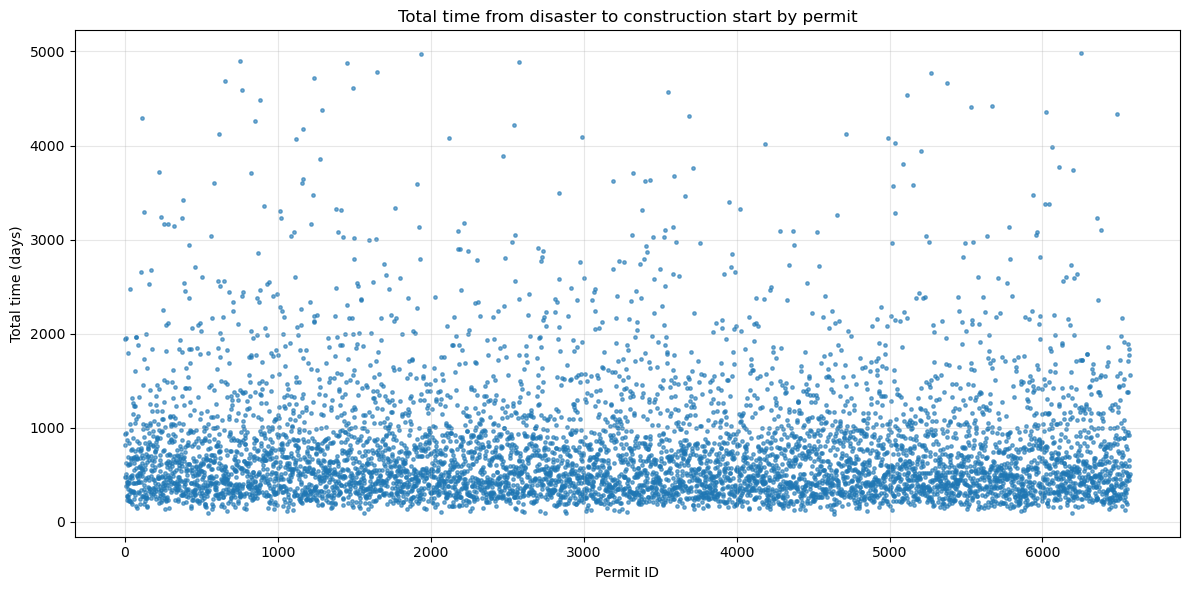

In [6]:
# Plot permit number (ID) vs total time to construction
import matplotlib.pyplot as plt

permit_ids = []
total_times = []

for p in sim.completed_permits:
    if p.ready_for_construction is not None and p.created_at is not None:
        permit_ids.append(p.permit_id)
        total_times.append(p.ready_for_construction - p.created_at)

plt.figure(figsize=(12, 6))
plt.scatter(permit_ids, total_times, s=6, alpha=0.6)
plt.xlabel("Permit ID")
plt.ylabel("Total time (days)")
plt.title("Total time from disaster to construction start by permit")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

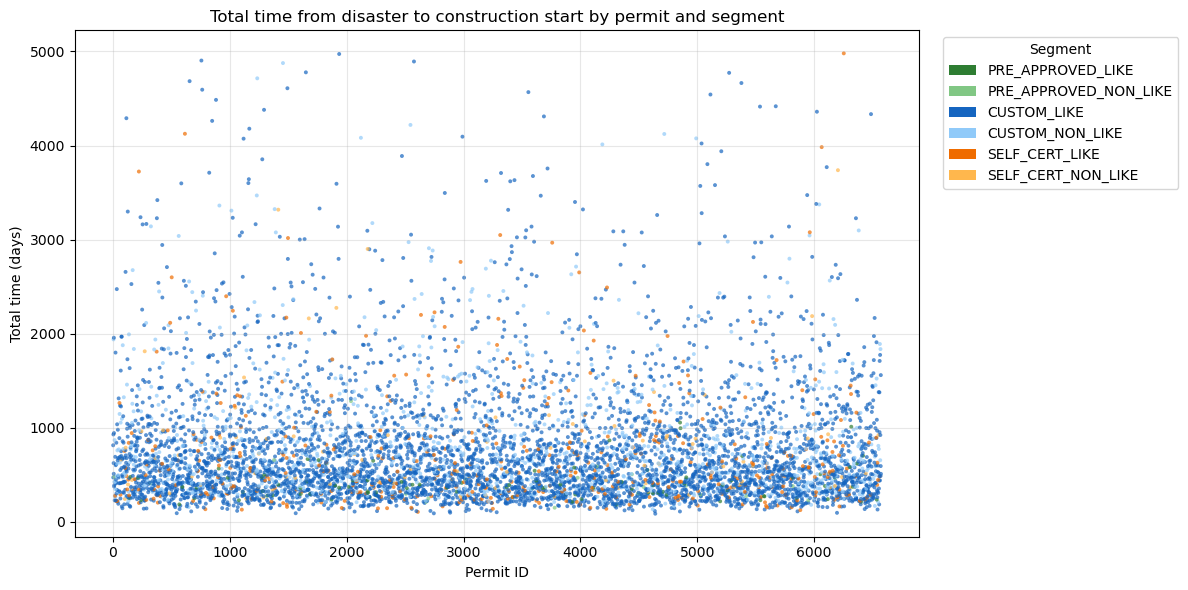

In [7]:
# Scatter plot: permit ID vs total time, colored by segment
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

permit_ids = []
total_times = []
segments = []

for p in sim.completed_permits:
    if p.ready_for_construction is None or p.created_at is None:
        continue
    permit_ids.append(p.permit_id)
    total_times.append(p.ready_for_construction - p.created_at)
    segments.append(p.segment)

# Define a color for each segment
from permit_simulation import Segment
segment_colors = {
    Segment.PRE_APPROVED_LIKE: "#2E7D32",      # green
    Segment.PRE_APPROVED_NON_LIKE: "#81C784",  # light green
    Segment.CUSTOM_LIKE: "#1565C0",            # blue
    Segment.CUSTOM_NON_LIKE: "#90CAF9",        # light blue
    Segment.SELF_CERT_LIKE: "#EF6C00",         # orange
    Segment.SELF_CERT_NON_LIKE: "#FFB74D",     # light orange,
}

colors = [segment_colors.get(seg, "#888888") for seg in segments]

plt.figure(figsize=(12, 6))
plt.scatter(permit_ids, total_times, c=colors, s=8, alpha=0.7, edgecolors="none")
plt.xlabel("Permit ID")
plt.ylabel("Total time (days)")
plt.title("Total time from disaster to construction start by permit and segment")
plt.grid(alpha=0.3)

# Legend
legend_patches = []
for seg, color in segment_colors.items():
    legend_patches.append(Patch(facecolor=color, edgecolor="none", label=seg.name))
plt.legend(handles=legend_patches, title="Segment", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

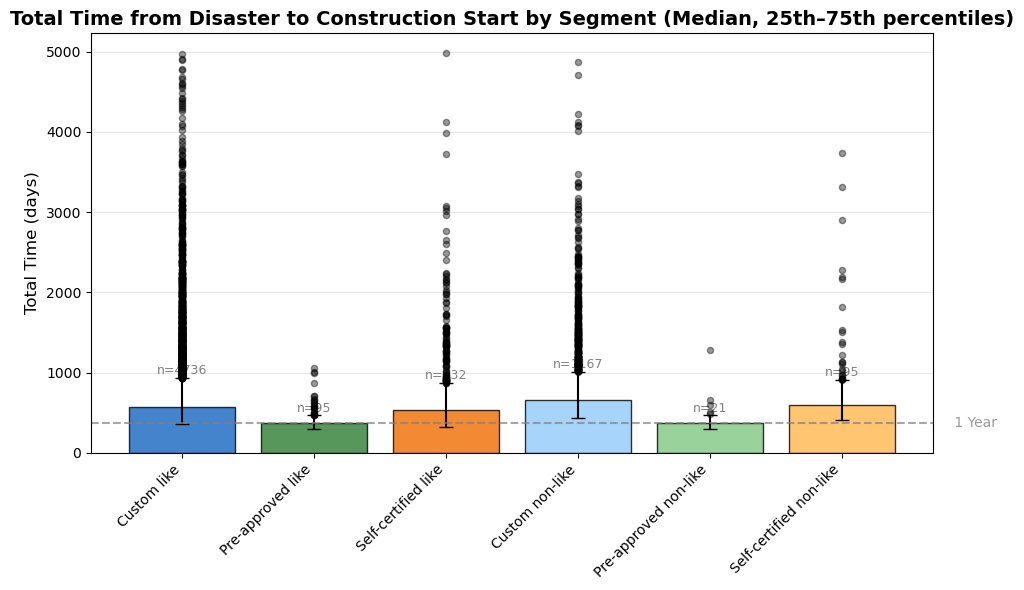

In [8]:
from visualize_permits import plot_total_time_by_segment_quartiles

fig, ax = plot_total_time_by_segment_quartiles(sim.completed_permits)
plt.show()

In [9]:
from run_simulation import run_simulation, print_statistics
import simpy

# Run the simulation
num_permits = 6571
print("Running simulation with " + str(num_permits) + " permits...")
# Scenario 2: Balanced segment allocation (50% pre-approved, 25% custom, 25% self-cert, 80% like-for-like)
sim_balanced = run_simulation(
    num_permits=num_permits,
    random_seed=42,
    inter_arrival_time=0,
    sequential = "standard",
    pct_pre_approved=0.5,
    pct_custom=0.25,
    pct_self_cert=0.25,
    pct_like_for_like=0.8,
)

# Get and display statistics
stats = sim_balanced.get_statistics()
print_statistics(stats)

Running simulation with 6571 permits...

SIMULATION STATISTICS

Total Completed Permits: 6559
Total In Progress: 12

--------------------------------------------------------------------------------
SEGMENT DISTRIBUTION
--------------------------------------------------------------------------------
  CUSTOM_LIKE                   : 1338 (20.40%)
  CUSTOM_NON_LIKE               :  313 ( 4.77%)
  PRE_APPROVED_LIKE             : 2601 (39.66%)
  PRE_APPROVED_NON_LIKE         :  661 (10.08%)
  SELF_CERT_LIKE                : 1334 (20.34%)
  SELF_CERT_NON_LIKE            :  312 ( 4.76%)

--------------------------------------------------------------------------------
OVERALL PROCESSING TIME STATISTICS
--------------------------------------------------------------------------------
  Mean:     593.75 days
  Median:   438.26 days
  Std Dev:  506.80 days
  Min:       83.04 days
  Max:     4963.58 days

--------------------------------------------------------------------------------
PROCESSING T

In [10]:
# Run multiple simulations for both segment-mix scenarios to see aggregate behavior
n_runs = 25

scenario_params_list = [
    {
        "name": "Default",
        "sequential": "standard",
    },
    {
        "name": "Balanced",
        "sequential": "standard",
        "pct_pre_approved": 0.5,
        "pct_custom": 0.25,
        "pct_self_cert": 0.25,
        "pct_like_for_like": 0.8,
    },
]

multi_results = run_multiple_simulations(
    n_runs=n_runs,
    num_permits=num_permits,
    simulation_duration=None,
    base_seed=42,
    inter_arrival_time=0.0,
    scenario_params_list=scenario_params_list,
    collect_permits=True,
)

all_default_permits: list = []
all_balanced_permits: list = []

for res in multi_results:
    scenario = res["scenario"]
    permits = res.get("permits", [])
    if scenario == "Default":
        all_default_permits.extend(permits)
    elif scenario == "Balanced":
        all_balanced_permits.extend(permits)


def _print_summary(name: str, permits: list) -> None:
    if not permits:
        print(f"{name}: no completed permits across runs")
        return
    total_times = np.array(
        [
            p.ready_for_construction - p.created_at
            for p in permits
            if getattr(p, "ready_for_construction", None) is not None
        ]
    )
    if total_times.size == 0:
        print(f"{name}: no permits with ready_for_construction timestamps")
        return

    print(
        f"{name}: n={len(total_times)}, mean={total_times.mean():.2f}, "
        f"median={np.median(total_times):.2f}"
    )


print(f"Ran {n_runs} runs per segment-mix scenario. Aggregate total-time stats:")
_print_summary("Default", all_default_permits)
_print_summary("Balanced", all_balanced_permits)

Ran 25 runs per segment-mix scenario. Aggregate total-time stats:
Default: n=163609, mean=776.33, median=575.49
Balanced: n=163942, mean=596.98, median=439.79


In [11]:
# Average (across runs) of each run's earliest debris start and latest debris end.

import statistics
from collections import defaultdict

by_scenario = defaultdict(
    lambda: {"epa_fs": [], "epa_le": [], "us_fs": [], "us_le": []}
)
all_epa_fs, all_epa_le, all_us_fs, all_us_le = [], [], [], []

for res in multi_results:
    st = res.get("stats") or {}
    if st.get("message"):
        continue
    epa = st.get("debris_removal_epa") or {}
    usc = st.get("debris_removal_usace") or {}
    e_fs = epa.get("first_service_start")
    e_le = epa.get("last_service_end")
    u_fs = usc.get("first_service_start")
    u_le = usc.get("last_service_end")
    if None in (e_fs, e_le, u_fs, u_le):
        continue
    scen = res["scenario"]
    b = by_scenario[scen]
    for lst, v in (
        (b["epa_fs"], e_fs),
        (b["epa_le"], e_le),
        (b["us_fs"], u_fs),
        (b["us_le"], u_le),
    ):
        lst.append(v)
    all_epa_fs.append(e_fs)
    all_epa_le.append(e_le)
    all_us_fs.append(u_fs)
    all_us_le.append(u_le)


def _debris_means_line(label, epa_fs, epa_le, us_fs, us_le):
    n = len(epa_fs)
    if n == 0:
        print(f"{label}: no complete runs")
        return
    print(f"{label} (n = {n} runs)")
    print(
        f"  EPA:   mean of first starts = {statistics.mean(epa_fs):.2f} d, "
        f"mean of last ends = {statistics.mean(epa_le):.2f} d"
    )
    print(
        f"  USACE: mean of first starts = {statistics.mean(us_fs):.2f} d, "
        f"mean of last ends = {statistics.mean(us_le):.2f} d"
    )


print("Debris calendar window — averages across simulations (days)\n")
_debris_means_line("All scenarios", all_epa_fs, all_epa_le, all_us_fs, all_us_le)
print()
for scen in sorted(by_scenario.keys()):
    b = by_scenario[scen]
    _debris_means_line(f"  {scen}", b["epa_fs"], b["epa_le"], b["us_fs"], b["us_le"])
    print()


Debris calendar window — averages across simulations (days)

All scenarios (n = 50 runs)
  EPA:   mean of first starts = 23.00 d, mean of last ends = 65.60 d
  USACE: mean of first starts = 23.00 d, mean of last ends = 167.02 d

  Balanced (n = 25 runs)
  EPA:   mean of first starts = 23.00 d, mean of last ends = 65.63 d
  USACE: mean of first starts = 23.00 d, mean of last ends = 167.01 d

  Default (n = 25 runs)
  EPA:   mean of first starts = 23.00 d, mean of last ends = 65.57 d
  USACE: mean of first starts = 23.00 d, mean of last ends = 167.02 d



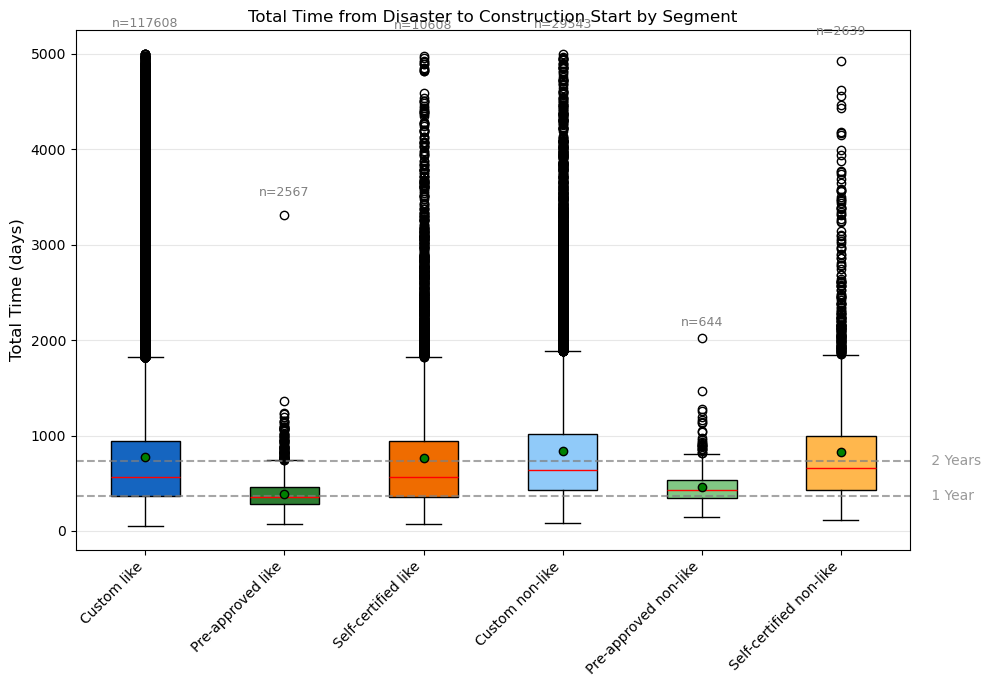

In [12]:
from visualize_permits import plot_total_time_by_segment
import matplotlib.pyplot as plt

# Box-and-whisker: Scenario 1 — Default segment allocation (aggregate across runs)
fig, ax = plot_total_time_by_segment(all_default_permits, figsize=(10, 7), show_boxplot=True)
if ax is not None:
    ax.set_title("Total Time from Disaster to Construction Start by Segment", fontsize=12)
plt.show()

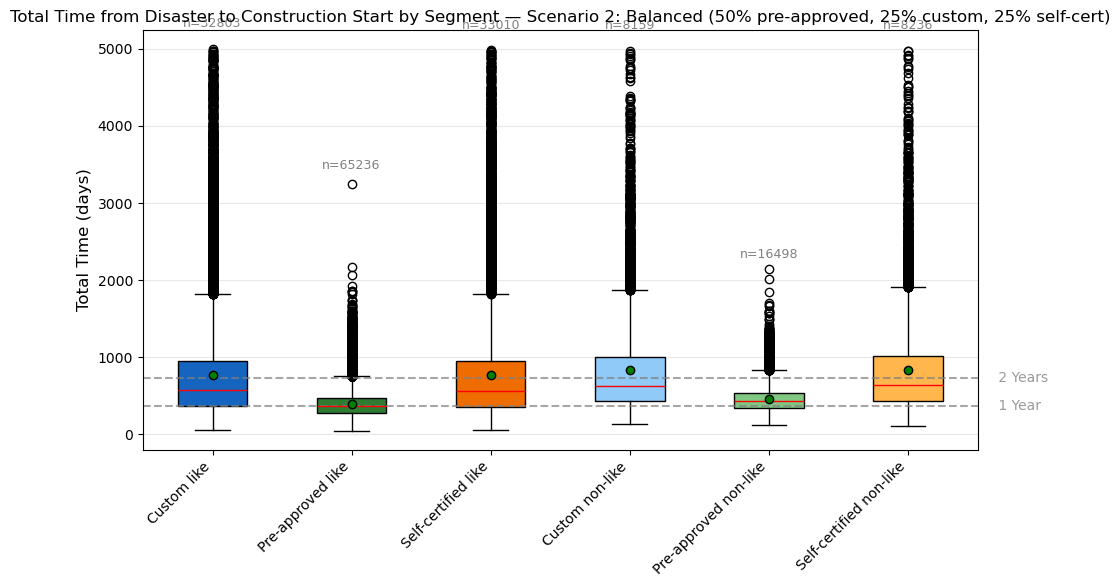

In [13]:
# Box-and-whisker: Scenario 2 — Balanced segment allocation (50% pre-approved, 25% custom, 25% self-cert, 80% like-for-like, aggregate across runs)
fig, ax = plot_total_time_by_segment(all_balanced_permits, figsize=(10, 6), show_boxplot=True)
if ax is not None:
    ax.set_title("Total Time from Disaster to Construction Start by Segment — Scenario 2: Balanced (50% pre-approved, 25% custom, 25% self-cert)", fontsize=12)
plt.show()

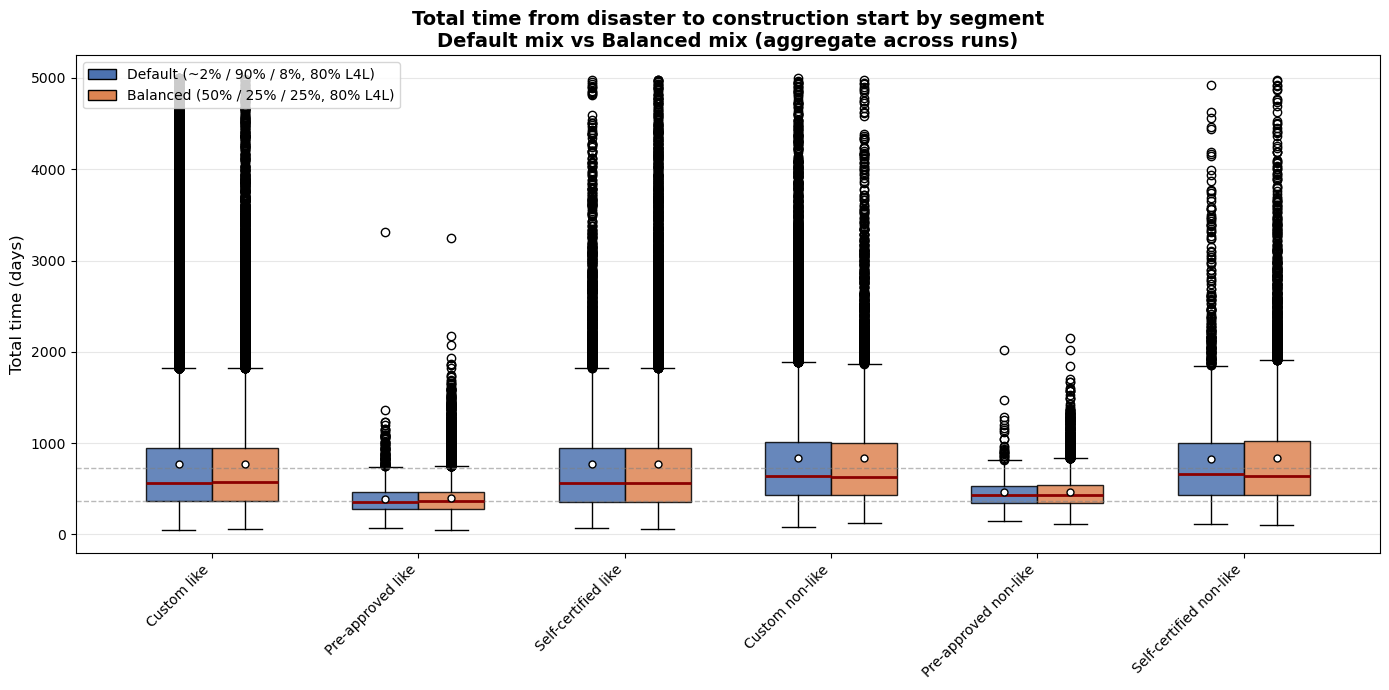

In [14]:
# Default vs Balanced segment mix — total time by segment (same figure)
# Requires: `all_default_permits`, `all_balanced_permits` from the multi-run cell above.

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from permit_simulation import Segment

if "all_default_permits" not in dir() or "all_balanced_permits" not in dir():
    raise NameError("Run the multi-run cell first to define all_default_permits and all_balanced_permits.")


def _total_times_by_segment(permits: list) -> dict:
    out: dict = {seg: [] for seg in Segment}
    for p in permits:
        if p.ready_for_construction is not None and p.created_at is not None:
            out[p.segment].append(float(p.ready_for_construction - p.created_at))
    return {s: v for s, v in out.items() if v}


segment_order = [
    Segment.CUSTOM_LIKE,
    Segment.PRE_APPROVED_LIKE,
    Segment.SELF_CERT_LIKE,
    Segment.CUSTOM_NON_LIKE,
    Segment.PRE_APPROVED_NON_LIKE,
    Segment.SELF_CERT_NON_LIKE,
]
label_by_segment = {
    Segment.PRE_APPROVED_LIKE: "Pre-approved like",
    Segment.PRE_APPROVED_NON_LIKE: "Pre-approved non-like",
    Segment.CUSTOM_LIKE: "Custom like",
    Segment.CUSTOM_NON_LIKE: "Custom non-like",
    Segment.SELF_CERT_LIKE: "Self-certified like",
    Segment.SELF_CERT_NON_LIKE: "Self-certified non-like",
}

sd = _total_times_by_segment(all_default_permits)
sb = _total_times_by_segment(all_balanced_permits)
segments = [s for s in segment_order if s in sd or s in sb]
if not segments:
    raise RuntimeError("No segment data in one or both scenarios.")

fig, ax = plt.subplots(figsize=(14, 7))
box_w = 0.32
color_default = "#4C72B0"
color_balanced = "#DD8452"

for i, s in enumerate(segments):
    dd, bd = sd.get(s, []), sb.get(s, [])
    if dd:
        ax.boxplot(
            dd,
            positions=[i - box_w / 2],
            widths=box_w,
            patch_artist=True,
            boxprops=dict(facecolor=color_default, alpha=0.85, edgecolor="black"),
            medianprops=dict(color="darkred", linewidth=2),
            meanprops=dict(marker="o", markeredgecolor="black", markerfacecolor="white", markersize=5),
            showmeans=True,
        )
    if bd:
        ax.boxplot(
            bd,
            positions=[i + box_w / 2],
            widths=box_w,
            patch_artist=True,
            boxprops=dict(facecolor=color_balanced, alpha=0.85, edgecolor="black"),
            medianprops=dict(color="darkred", linewidth=2),
            meanprops=dict(marker="o", markeredgecolor="black", markerfacecolor="white", markersize=5),
            showmeans=True,
        )

ax.set_xticks(range(len(segments)))
ax.set_xticklabels([label_by_segment[s] for s in segments], rotation=45, ha="right")
ax.set_ylabel("Total time (days)", fontsize=12)
ax.set_title(
    "Total time from disaster to construction start by segment\nDefault mix vs Balanced mix (aggregate across runs)",
    fontsize=14,
    fontweight="bold",
)
ax.grid(axis="y", alpha=0.3)
for y_line, label in [(365, "1 yr"), (730, "2 yr")]:
    ax.axhline(y=y_line, color="gray", linestyle="--", linewidth=1, alpha=0.55)
ax.legend(
    handles=[
        Patch(facecolor=color_default, edgecolor="black", label="Default (~2% / 90% / 8%, 80% L4L)"),
        Patch(facecolor=color_balanced, edgecolor="black", label="Balanced (50% / 25% / 25%, 80% L4L)"),
    ],
    loc="upper left",
    fontsize=10,
)
plt.tight_layout()
plt.show()


Average waiting and service time by step (days):
  EPA Debris: waiting mean=19.97, σ=11.88; service mean=1.01, σ=0.49
  USACE Debris: waiting mean=48.80, σ=28.71; service mean=2.49, σ=0.50
  Pre-Application Activities: waiting mean=0.00, σ=0.00; service mean=647.18, σ=630.97
  Planning: waiting mean=0.00, σ=0.00; service mean=6.79, σ=1.81
  Special Zoning: waiting mean=0.00, σ=0.00; service mean=58.78, σ=46.24
  Public Works: waiting mean=0.00, σ=0.00; service mean=8.33, σ=2.89
  Agency Referral: waiting mean=0.00, σ=0.00; service mean=36.85, σ=26.83
  Fire Review: waiting mean=0.00, σ=0.06; service mean=4.68, σ=3.61
  Applicant Revisions: waiting mean=0.00, σ=0.00; service mean=95.82, σ=40.21


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Average Total Waiting vs Service Time by Process Step'}, xlabel='Process Step', ylabel='Average Time (days)'>)

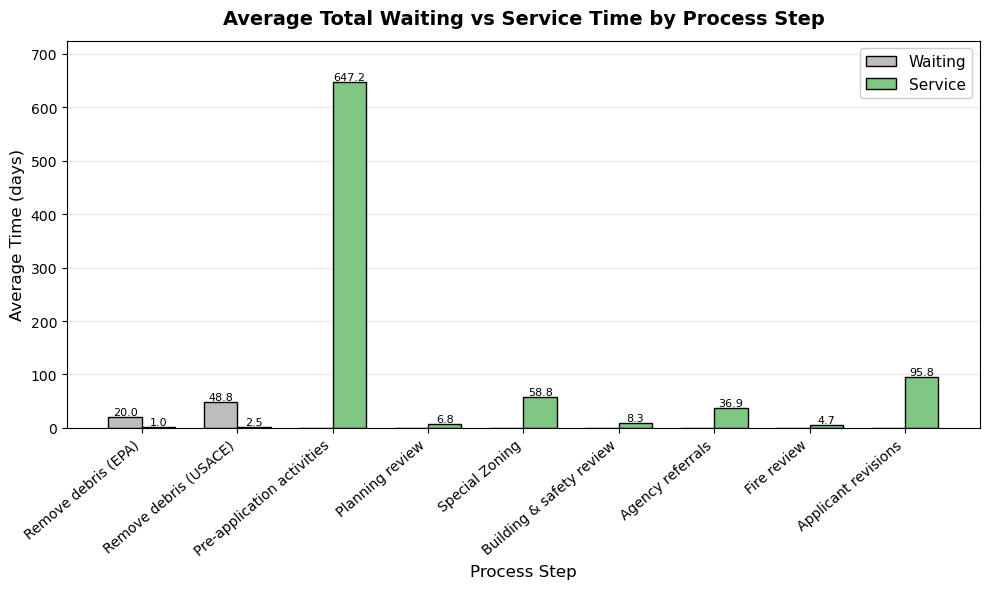

In [15]:
# Visualize the time each permit spends in each stage
from visualize_permits import plot_average_waiting_and_service_by_step


# Visualize aggregate time spent in each process stage across all runs
label_map = {
    "EPA Debris": "Remove debris (EPA)",
    "USACE Debris": "Remove debris (USACE)",
    "Pre-Application Activities": "Pre-application activities",
    "Planning": "Planning review",
    "Special Zoning Review": "Special zoning review",
    "Public Works": "Building & safety review",
    "Agency Referral": "Agency referrals",
    "Fire Review": "Fire review",
    "Applicant Revisions": "Applicant revisions",
}
plot_average_waiting_and_service_by_step(sim.completed_permits, label_map=label_map)